<a href="https://colab.research.google.com/github/IsabelaBersan/tech-challenge-fase2/blob/main/notebooks_01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## 1. Compreensão do Problema

### 1.1 Contexto

O conjunto de dados Wine Quality Dataset reúne medições físico-químicas de amostras de vinho tinto (acidez, açúcar residual, cloretos, dióxido de enxofre, densidade, pH, sulfatos, teor alcoólico) associadas a uma nota de qualidade sensorial atribuída por avaliadores (escala de 0 a 10). O objetivo de negócio típico deste tipo de dataset é apoiar produtores/enólogos na identificação de quais características físico-químicas estão associadas a vinhos de melhor qualidade, permitindo ajustes no processo produtivo e triagem mais objetiva.

### 1.2 Variável alvo

A variável `quality` (inteiro, 3 a 8 no dataset) é a variável alvo original. Ela representa a nota de qualidade sensorial atribuída ao vinho.

In [ ]:
df = pd.read_csv("wine.csv", sep = ",")

In [ ]:
df.shape

(1143, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
print("\nValores nulos por coluna:")
print(df.isnull().sum())
print("\nLinhas duplicadas:", df.duplicated().sum())


Valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Linhas duplicadas: 0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


### 1.2.1 Conhecendo o conteúdo dos dados da coluna "Quality"

In [ ]:
set(df['quality'])

{3, 4, 5, 6, 7, 8}

### 1.3 Transformação em classificação binária

Foi criada a variável `quality_binary` com o seguinte critério:

- `quality ≥ 6` → **1** (vinho classificado como "bom")
- `quality < 6` → **0** (vinho classificado como "regular/ruim")

**Justificativa da escolha (em vez do corte `≥ 7` usado como exemplo no enunciado):**

O enunciado apresenta o corte `quality ≥ 7` apenas *como exemplo* de transformação em classificação binária, não como uma exigência fixa. Optou-se por `quality ≥ 6` pelos seguintes motivos:

1. **Tamanho da amostra positiva:** com `≥ 7`, apenas 159 das 1.143 amostras (13,9%) ficam na classe "alta qualidade". Em um dataset já pequeno, isso deixa poucos exemplos positivos para o modelo aprender e, principalmente, poucos exemplos na parte de teste para avaliar a classe minoritária com confiança, qualquer split treino/teste tende a gerar métricas instáveis (alta variância) para essa classe.
2. **Balanceamento mais adequado à comparação de modelos:** com `≥ 6`, a proporção fica em 54,3% (classe 1) vs. 45,7% (classe 0), próxima do equilíbrio. Isso permite comparar honestamente o desempenho de diferentes modelos usando métricas simples (ex.: acurácia), sem depender de técnicas de reamostragem artificial (SMOTE, undersampling), que podem introduzir ruído sintético ou descartar dados reais.
3. **Sentido prático do limiar:** a nota 6 corresponde à mediana/moda da distribuição de `quality` neste conjunto (seção 2.1), o que a torna um limiar natural de "aprovação" dentro da escala usada pelos avaliadores, separando vinhos com avaliação igual ou acima da mais comum das amostras com avaliação abaixo dela. Já o corte `≥ 7` isola apenas os vinhos de excelência, um recorte útil para outra pergunta de negócio (identificar os poucos vinhos "premium"), mas menos representativo da maioria dos vinhos de qualidade satisfatória.

Como referência de sensibilidade, o corte alternativo `quality ≥ 7` também é calculado e comparado abaixo, mas **não é o critério adotado no pipeline principal** deste trabalho.


In [ ]:
df = df.drop(columns=['Id'])  # Id é apenas identificador

# Corte adotado: quality >= 6 (ver justificativa na seção 1.3)
df['quality_binary'] = (df['quality'] >= 6).astype(int)

bal = df['quality_binary'].value_counts()
bal_pct = df['quality_binary'].value_counts(normalize=True) * 100
print("=== Balanceamento (corte >=6, adotado) ===")
print(bal)
print(bal_pct.round(2))

# Corte alternativo (exemplo do enunciado), apenas para referência de sensibilidade
alt = (df['quality'] >= 7).astype(int)
print("\n=== Balanceamento alternativo (corte >=7, exemplo do enunciado) ===")
print(alt.value_counts())
print((alt.value_counts(normalize=True) * 100).round(2))


=== Balanceamento (corte >=6, adotado) ===
quality_binary
1    621
0    522
Name: count, dtype: int64
quality_binary
1    54.33
0    45.67
Name: proportion, dtype: float64

=== Balanceamento alternativo (corte >=7, exemplo do enunciado) ===
quality
0    984
1    159
Name: count, dtype: int64
quality
0    86.09
1    13.91
Name: proportion, dtype: float64


In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


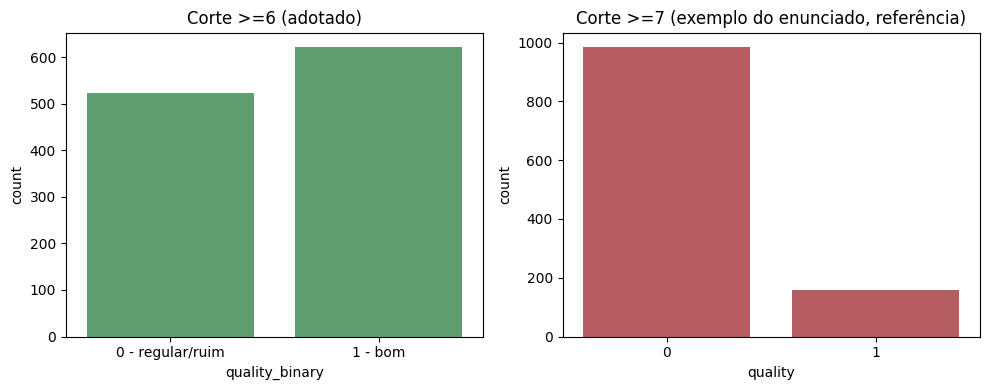

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=df['quality_binary'], ax=axes[0], color='#55A868')
axes[0].set_title('Corte >=6 (adotado)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0 - regular/ruim', '1 - bom'])
sns.countplot(x=alt, ax=axes[1], color='#C44E52')
axes[1].set_title('Corte >=7 (exemplo do enunciado, referência)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['0', '1'])
plt.tight_layout()
plt.show()


## 2. Análise Exploratória de Dados (EDA)

### 2.1 Distribuição das variáveis

A variável `quality` concentra-se nas notas 5 e 6 (juntas, 82,7% das amostras), com poucas amostras nos extremos (nota 3: 6 casos; nota 8: 16 casos), caracterizando uma distribuição aproximadamente normal e centrada.

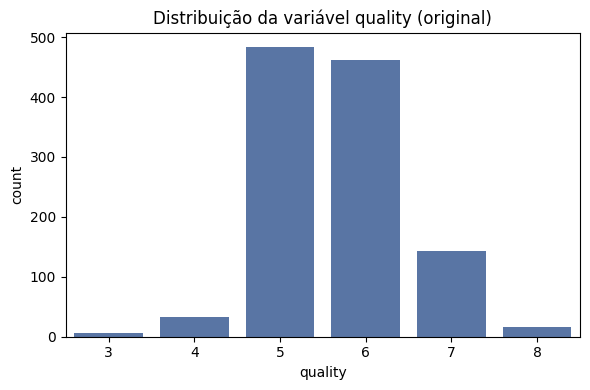

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='quality', data=df, ax=ax, color='#4C72B0')
ax.set_title('Distribuição da variável quality (original)')
plt.tight_layout()
plt.show()

print(df['quality'].value_counts().sort_index())

As variáveis físico-químicas numéricas foram inspecionadas via histogramas com estimativa de densidade (KDE):

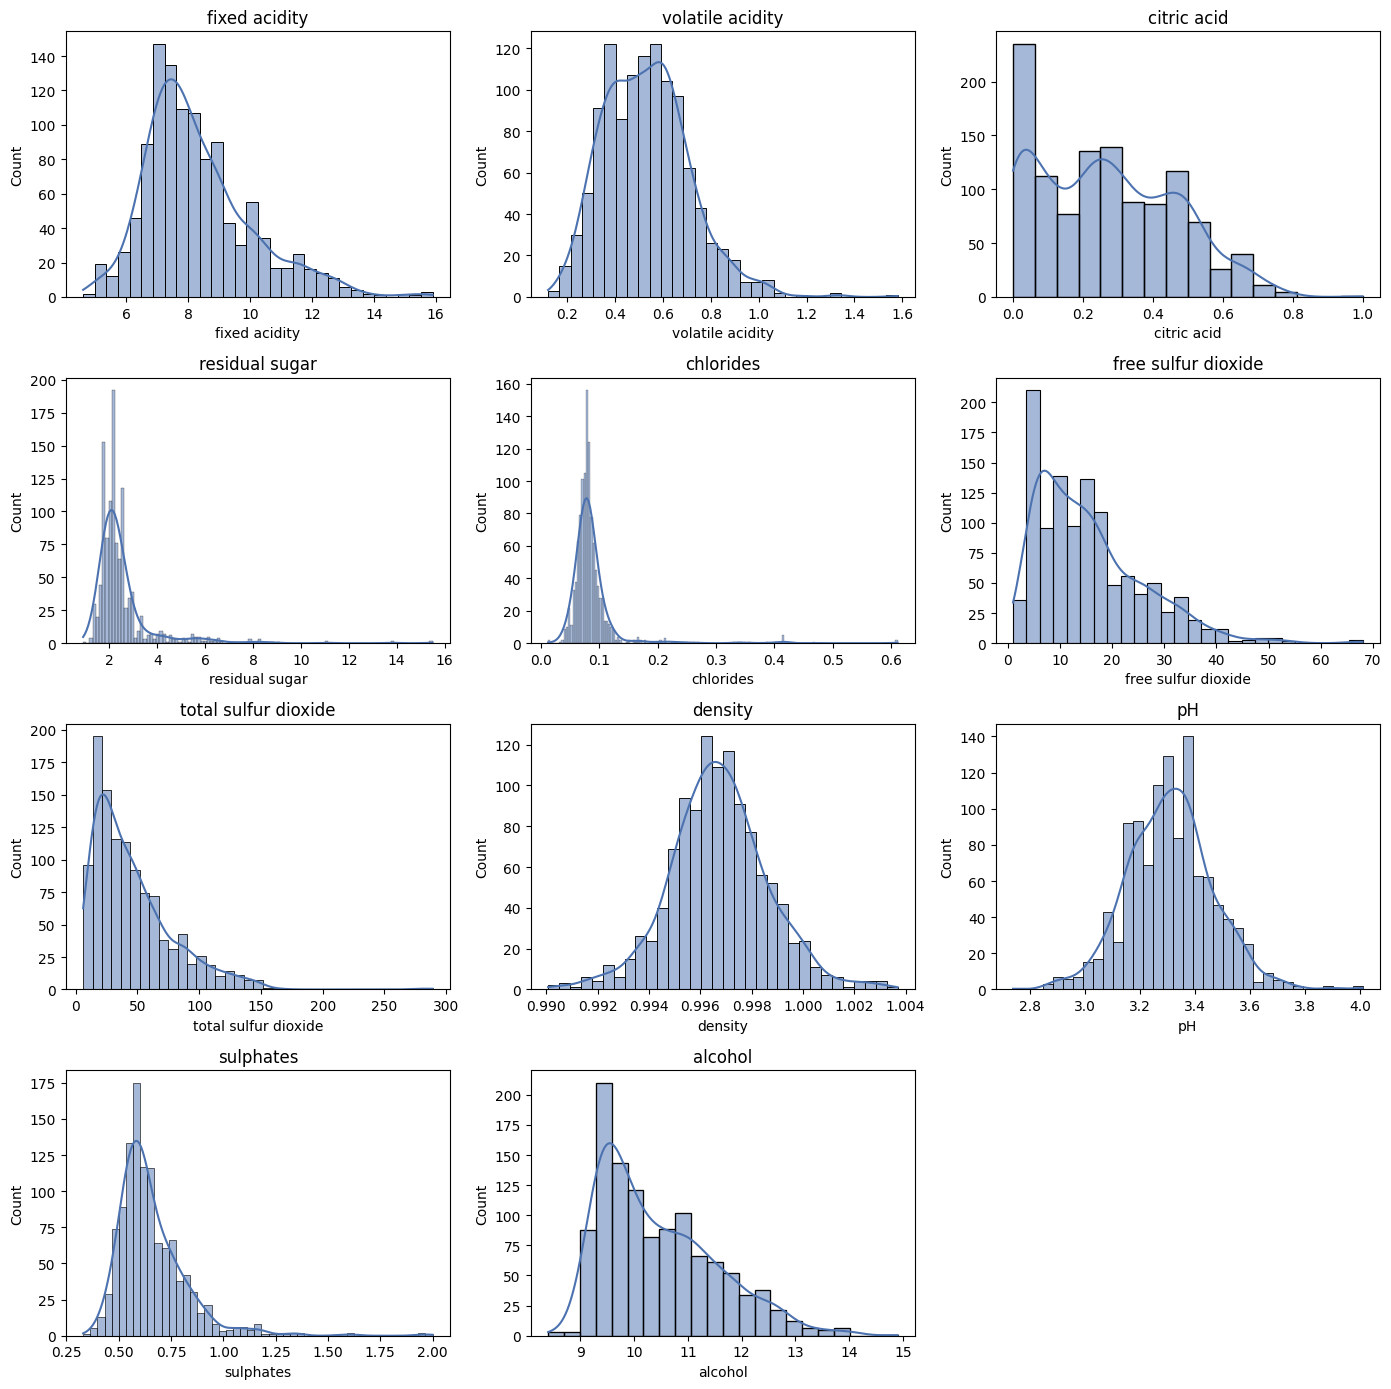

In [ ]:
num_cols = [c for c in df.columns if c not in ['quality', 'quality_binary']]

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

- **fixed acidity, volatile acidity, sulphates, chlorides e residual sugar:** distribuições assimétricas à direita (cauda longa), sugerindo presença de valores extremos.
- **citric acid:** distribuição com massa considerável em 0, comum em vinhos sem adição de ácido cítrico.
- **pH, density e alcohol:** aproximam-se mais de uma distribuição simétrica/normal.
- **total sulfur dioxide e free sulfur dioxide:** caudas longas à direita, com poucos valores muito altos.


### 2.2 Correlações entre variáveis e justificativa

A matriz de correlação de Pearson foi calculada entre todas as variáveis numéricas, incluindo a variável `quality` original:

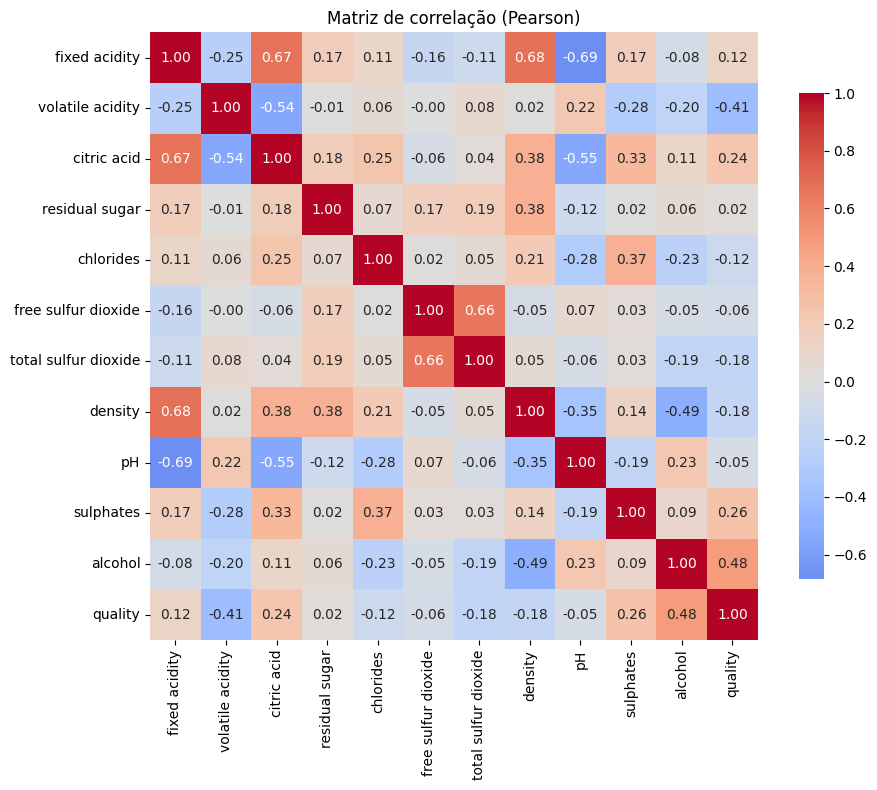

Correlação com quality (ordenada):
quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


In [ ]:
corr = df[num_cols + ['quality']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlação (Pearson)')
plt.tight_layout()
plt.show()

print("Correlação com quality (ordenada):")
print(corr['quality'].sort_values(ascending=False))

### 2.2.1 Justificativa das correlações mais relevantes

As correlações mais fortes com `quality` (confirmadas a partir da matriz acima) são:

- **alcohol (+0,48):** correlação positiva mais forte do conjunto. Vinhos com maior teor alcoólico tendem a receber notas de qualidade mais altas, possivelmente associado a maior corpo/concentração do vinho, características valorizadas na avaliação sensorial.
- **volatile acidity (−0,41):** correlação negativa mais forte. A acidez volátil elevada está associada a defeitos sensoriais (gosto e odor de vinagre, causados por bactérias acéticas), o que explica a penalização na nota de qualidade.
- **sulphates (+0,26):** sulfatos atuam como conservantes e antioxidantes; em níveis adequados, contribuem para a estabilidade do vinho e podem estar associados a amostras melhor avaliadas.
- **citric acid (+0,24):** o ácido cítrico contribui para frescor e equilíbrio de acidez, características geralmente associadas a vinhos de melhor qualidade.
- **total sulfur dioxide (−0,18) e density (−0,18):** correlações negativas mais fracas; teores excessivos de SO₂ total podem indicar conservação química mais agressiva, e densidades mais altas costumam estar associadas a maior açúcar residual, geralmente menos valorizado neste conjunto.

As demais variáveis (`residual sugar`, `pH`, `free sulfur dioxide`, `chlorides`, `fixed acidity`) apresentam correlação fraca (|r| < 0,15) com a qualidade, isoladamente.


### 2.3 Outliers e valores inconsistentes

Para identificar possíveis outliers nas variáveis físico-químicas, foi aplicada a regra do intervalo interquartil (IQR): valores abaixo de `Q1 - 1.5*IQR` ou acima de `Q3 + 1.5*IQR` são sinalizados como outliers.


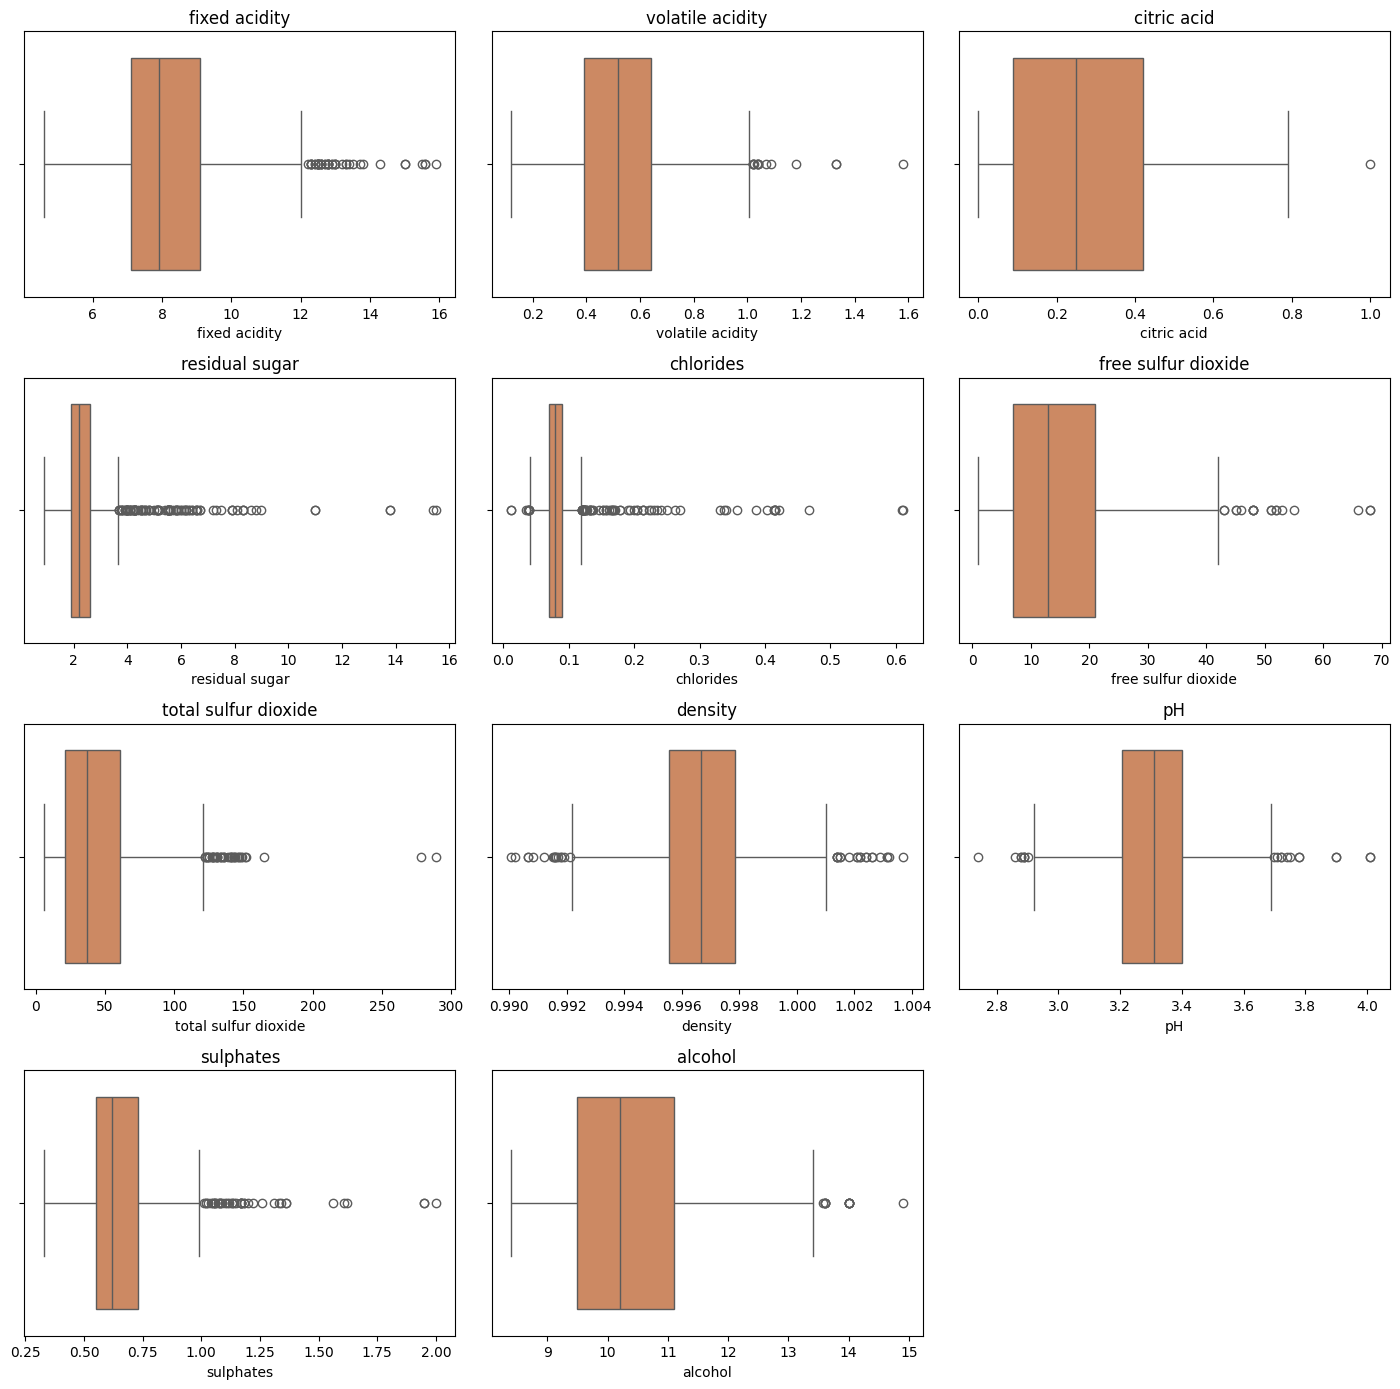

Percentual de outliers por variável (regra IQR):
fixed acidity: 44 outliers (3.8%)
volatile acidity: 14 outliers (1.2%)
citric acid: 1 outliers (0.1%)
residual sugar: 110 outliers (9.6%)
chlorides: 77 outliers (6.7%)
free sulfur dioxide: 18 outliers (1.6%)
total sulfur dioxide: 40 outliers (3.5%)
density: 36 outliers (3.1%)
pH: 20 outliers (1.7%)
sulphates: 43 outliers (3.8%)
alcohol: 12 outliers (1.0%)


In [ ]:
num_cols = [c for c in df.columns if c not in ['quality', 'quality_binary']]

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='#DD8452')
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

print("Percentual de outliers por variável (regra IQR):")
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    print(f"{col}: {n_out} outliers ({n_out/len(df)*100:.1f}%)")


As variáveis com maior percentual de outliers pela regra do IQR são **residual sugar (9,6%)**, **chlorides (6,7%)**, **fixed acidity (3,8%)**, **sulphates (3,8%)**, **total sulfur dioxide (3,5%)** e **density (3,1%)**. As demais variáveis apresentam menos de 2% de valores atípicos.

Esses outliers não parecem ser erros de digitação ou valores fisicamente impossíveis (todos os valores mínimos e máximos observados estão dentro de faixas plausíveis para vinho tinto), e sim variabilidade natural do processo produtivo. Por isso, optou-se por **não remover** essas observações nesta etapa — a decisão sobre tratamento (manter, transformar via log ou usar modelos robustos a outliers) será revisitada na etapa de modelagem, conforme o algoritmo escolhido.


### 2.4 Duplicatas e valores inconsistentes

A checagem inicial (`df.duplicated().sum()`, seção 1) não identificou duplicatas porque a coluna `Id` é um identificador único por linha, o que impede qualquer duplicata exata enquanto ela estiver presente na comparação. Refazendo a checagem apenas com as variáveis físico-químicas e a nota `quality` (sem o `Id`, já removido do `df`), foram encontradas duplicatas reais:


In [ ]:
n_dup = df[num_cols + ['quality']].duplicated().sum()
print(f"Linhas com perfil físico-químico e quality idênticos: {n_dup}")
print(f"Percentual do total: {n_dup/len(df)*100:.1f}%")


Linhas com perfil físico-químico e quality idênticos: 125
Percentual do total: 10.9%


Foram encontradas **125 linhas (10,9% do total)** com todas as variáveis físico-químicas e a nota de `quality` idênticas às de outra linha — apenas o `Id` (já removido) diferia. Isso é plausível em datasets de vinho, nos quais diferentes lotes/amostras podem apresentar medições muito próximas ou coincidentes. **Optou-se por manter essas linhas no dataset**, pois representam observações válidas (não é erro de coleta) e removê-las reduziria o tamanho da amostra sem garantia de ganho real de qualidade dos dados. Essa decisão poderá ser revisitada durante a modelagem, caso se observe vazamento de informação entre treino e teste (ex.: linhas duplicadas caindo simultaneamente em treino e teste).



### 2.5 Balanceamento das classes

Com o corte adotado (`quality ≥ 6`), a proporção de classes é **54,3% (classe 1 — bom) vs. 45,7% (classe 0 — regular/ruim)**, um leve desbalanceamento, tratável sem técnicas especiais de reamostragem — reforçando a justificativa apresentada na seção 1.3 para a escolha desse corte.

Já o corte alternativo (`quality ≥ 7`, exemplo do enunciado), mantido apenas como referência de sensibilidade, geraria **13,9% vs. 86,1%**, um desbalanceamento severo que exigiria estratégias como SMOTE, undersampling ou ajuste de peso das classes (`class_weight`) caso fosse adotado — o que reforça, na prática, a decisão de não utilizá-lo como critério principal.
